# MIDTERM ESSAY
# Applied Probability and Statistics for Information Technology

**STUDENT'S NAME:**

**STUDENT ID:**

**CLASS and GROUP:**

Students submit this jupyter notebook presenting your solution and coding. Students giving correct solutions by using Markdown and typing your codes.

Save and submit only 1 file as: Student name_StudentID.ipynb (Example: TranVanAn_203456.ipynb)

You should solve and submit this report to your theory Google classroom within 14 days, from the beginning of Nov 1st 2024 to the end of Nov 14th 2024. Late submissions are not accepted. Submissions via email are not accepted.

This is an individual final report. NOT ALLOWED TO USE GOOGLE, CHATGPT, etc for copying similar solutions and codes. Any case of plagiarism will get 0.

# Question 1: (2 points)
A closed urn has 23 balls: 8 white, 6 blue and 9 red.

In [ ]:
def cross(A, n):
    return {a+str(b+1) for a in A for b in range(n)}

urn = cross('W', 8) | cross('B', 6) | cross('R', 9)

Randomly select ***x*** balls
(know that each ball has the same probability of selection).

Use two last digits in your Student ID to get value x.

For example: Student ID: 0412347 => 47

In [ ]:
def get_x(n):
    return int(( n / 99 ) * 4 + 6)

x = get_x(47)

Find a list of all possible ***x*** balls and assign to variable $U$.

In [3]:
import itertools
import math

def cross(A, n):
    return {a+str(b+1) for a in A for b in range(n)}

urn = cross('W', 8) | cross('B', 6) | cross('R', 9)

def get_x(n):
    return int(( n / 99 ) * 4 + 6)

# IMPORTANT: Replace 47 with the last two digits of your actual Student ID
student_id_last_2_digits = 47 
x = get_x(student_id_last_2_digits)
print(f"x = {x}")

# Find a list of all possible x balls and assign to variable U
U = list(itertools.combinations(urn, x))
print(f"Total combinations in U: {len(U)}")


x = 7
Total combinations in U: 245157


Let *X* represent the random variable corresponding to the number of red balls in ***x*** balls.

Let *Y* represent the random variable corresponding to the number of white balls in ***x*** balls.

Compute the probability:
$P(X=3|Y=1)$ (present the steps along with illustrative code).

In [ ]:
count_Y1 = 0
count_X3_Y1 = 0

for combo in U:
    reds = sum(1 for ball in combo if ball.startswith('R'))
    whites = sum(1 for ball in combo if ball.startswith('W'))
    
    if whites == 1:
        count_Y1 += 1
        if reds == 3:
            count_X3_Y1 += 1

probability = count_X3_Y1 / count_Y1 if count_Y1 > 0 else 0

print(f"Number of outcomes where Y=1 (exactly 1 white): {count_Y1}")
print(f"Number of outcomes where X=3 and Y=1: {count_X3_Y1}")
print(f"P(X=3 | Y=1) = {probability:.5f}")

Number of outcomes where Y=1 (exactly 1 white): 40040
Number of outcomes where X=3 and Y=1: 13440
P(X=3 | Y=1) = 0.33566


# Question 2: (3 points)

Study the statistical functions from the *scipy* library to solve the following questions.

**For each question, it is necessary to present the corresponding function, including its prototype, input, output, and the meaning of its parameters.** (1 point)

**2.1 (0.5 point):** Consider a random variable that follows normal distribution with mean 6 and variance 12. Calculate:

a) $P(X < 2)$

b) $P(4 \leq X \leq 8)$

In [5]:
import scipy.stats as stats
import numpy as np
# a) P(X < 2)
# Since variance = 12, standard deviation (scale) = sqrt(12)
prob_a = stats.norm.cdf(2, loc=6, scale=np.sqrt(12))
print(f"a) P(X < 2) = {prob_a:.5f}")

# b) P(4 <= X <= 8) = P(X <= 8) - P(X < 4)
prob_b = stats.norm.cdf(8, loc=6, scale=np.sqrt(12)) - stats.norm.cdf(4, loc=6, scale=np.sqrt(12))
print(f"b) P(4 <= X <= 8) = {prob_b:.5f}")

a) P(X < 2) = 0.12411
b) P(4 <= X <= 8) = 0.43630


**2.2 (0.5 point):** The number of bicycles crossing a bridge during the day follow a Poisson distribution with mean 28. What is the probability that on a randomly selected day 15 bicycles would have crossed the bridge?

In [6]:
# P(X = 15)
prob_15_bikes = stats.poisson.pmf(15, mu=28)
print(f"P(15 bicycles) = {prob_15_bikes:.5f}")

P(15 bicycles) = 0.00270


**2.3 (0.5 point):** Suppose that service times at a call center are exponentially distributed with an average call lasting 8 minutes. If there are 3 call center agents serving calls, what is the probability that each person completes his or her work in 10 minutes? Assume that the duration of each call is independent of every other call.

In [7]:
# P(X <= 10) for one person
prob_one_person = stats.expon.cdf(10, scale=8)

# Since the 3 calls are independent, we multiply the probability for all 3
prob_three_people = prob_one_person ** 3
print(f"Probability each of 3 people finishes in 10 mins = {prob_three_people:.5f}")

Probability each of 3 people finishes in 10 mins = 0.36322


**2.4 (0.5 point):** From the experience, it is seen that 5% of the tyres produced by the machine are defective. Out of the 10 tyres produced, find the probability that at most 4 are defective.

In [8]:
# P(X <= 4)
prob_at_most_4 = stats.binom.cdf(4, n=10, p=0.05)
print(f"Probability at most 4 are defective = {prob_at_most_4:.5f}")

Probability at most 4 are defective = 0.99994


# Question 3: Using Monte Carlo method to estimate π (1.5 points)

**Consider a circle C centered at (0,0) with a diameter of 1.** This question asks students to explore how the Monte Carlo method can be used to estimate the value of π through random number generation. Students need to draw illustrations (by code or hand-drawn). (1 point)


```
# your answer
```

Now, imagine a square that circumscribes the circle. Randomly select points within the square, and use the Monte Carlo method to estimate the value of π based on the proportion of points that fall inside the circle. Write a simulator function of selecting point n times to estimate the π number. (1 point)

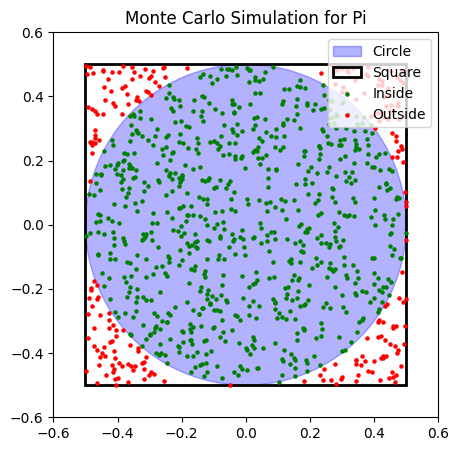

Estimated value of Pi using 100000 points: 3.14796


In [9]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5,5))
circle = plt.Circle((0, 0), 0.5, color='blue', alpha=0.3, label='Circle')
square = plt.Rectangle((-0.5, -0.5), 1, 1, fill=False, color='black', linewidth=2, label='Square')
ax.add_patch(circle)
ax.add_patch(square)

pts_x = np.random.uniform(-0.5, 0.5, 1000)
pts_y = np.random.uniform(-0.5, 0.5, 1000)
inside = (pts_x**2 + pts_y**2) <= 0.25

ax.scatter(pts_x[inside], pts_y[inside], color='green', s=5, label='Inside')
ax.scatter(pts_x[~inside], pts_y[~inside], color='red', s=5, label='Outside')

ax.set_xlim(-0.6, 0.6)
ax.set_ylim(-0.6, 0.6)
ax.set_aspect('equal')
plt.title("Monte Carlo Simulation for Pi")
plt.legend(loc="upper right")
plt.show()

def estimate_pi(n):
    # Randomly select points x, y uniformly between -0.5 and 0.5
    x = np.random.uniform(-0.5, 0.5, n)
    y = np.random.uniform(-0.5, 0.5, n)
    
    # Check if points fall inside the circle using the Pythagorean theorem (x^2 + y^2 <= r^2)
    # The radius r is 0.5, so r^2 is 0.25
    inside_circle = np.sum((x**2 + y**2) <= 0.25)
    
    # Estimate pi based on the proportion
    pi = 4 * (inside_circle / n)
    return pi

n_trials = 100000
estimated_value = estimate_pi(n_trials)
print(f"Estimated value of Pi using {n_trials} points: {estimated_value}")

# Question 4: Estimating the population mean from sample mean (2.0 points)

Let $\{X_1, X_2, \ldots, X_{30}\}$ be a random sample from the population with an unknown probability density function f(x,θ), where θ∈Θ. We have **equation (1): $E[\bar{X}]=\mu$**.
Let the population consist of 10000 elements, as described above. Please explain each step to demonstrate Equation (1) by selecting a random sample of size 30 from the population's distribution, including illustrative code.
```
Need to use your STUDENT ID to get the value for the code below. READ COMMENT IN CODE.
```

In [14]:
import numpy as np

# IMPORTANT: Use your STUDENT ID to get the value for the code below.
a = 52 
b = 12 

# 1. Define the Population
np.random.seed(42) # Set seed for reproducibility
population_data = list(np.random.normal(a, b, 10000))

# 2. Calculate the True Population Mean
mu = np.mean(population_data)
print(f"True Population Mean (mu): {mu:.4f}")

# 3 & 4. Draw many samples of size 30 and calculate their means
sample_size = 30
number_of_samples = 5000 
sample_means = []

for _ in range(number_of_samples):
    # Draw a random sample of size 30 without replacement
    sample = np.random.choice(population_data, size=sample_size, replace=False)
    # Calculate the mean of this sample (X_bar)
    sample_mean = np.mean(sample)
    sample_means.append(sample_mean)

# 5. Calculate Expected Value of the Sample Means E[X_bar]
expected_value_X_bar = np.mean(sample_means)

# 6. Comparison
print(f"Expected Value of Sample Means E[X_bar]: {expected_value_X_bar:.4f}")
print(f"Difference between E[X_bar] and mu: {abs(expected_value_X_bar - mu):.6f}")
print("Conclusion: Since E[X_bar] is approximately equal to mu, Equation (1) is demonstrated.")

True Population Mean (mu): 51.9744
Expected Value of Sample Means E[X_bar]: 51.9537
Difference between E[X_bar] and mu: 0.020684
Conclusion: Since E[X_bar] is approximately equal to mu, Equation (1) is demonstrated.



```
# Your answer
```

# Question 5: (1.5 points) [Spam email classification]
We're now trying to find if emails are spam. Let's say that we have a big data set of 100 emails, and 20 of them are actually spam. So we want to build a classifier. The easiest classifier that we can find is one that says that everything is spam with a 20% probability, because that's all we know so far. So that's a pretty simple classifier. We want to find something more elaborate, and so we're going to look at a feature.

We're going to start noticing that the spam emails tend to have words like "lottery". So we're going to try to put the word "lottery" into our spam detector. We're going to do the following, we're going to see how many emails among the spam ones contain the word “lottery” and we notice that there's 14 of them. Now we're going to look at how many of the emails that are not spam, have the word "lottery". So there's 10 of them. So now, what is the probability that an email containing the word "lottery" is spam?

In [12]:
# Given data
total_emails = 100
total_spam = 20

# Features observed
spam_with_lottery = 14
not_spam_with_lottery = 10

# Calculate total number of emails containing the word 'lottery'
total_with_lottery = spam_with_lottery + not_spam_with_lottery

# Calculate Conditional Probability P(Spam | Lottery)
# P(Spam | Lottery) = (Spam emails containing 'lottery') / (Total emails containing 'lottery')
prob_spam_given_lottery = spam_with_lottery / total_with_lottery

print(f"Total emails with the word 'lottery': {total_with_lottery}")
print(f"Number of those that are actually spam: {spam_with_lottery}")
print(f"P(Spam | Lottery) = {spam_with_lottery} / {total_with_lottery} = {prob_spam_given_lottery:.4f}")

Total emails with the word 'lottery': 24
Number of those that are actually spam: 14
P(Spam | Lottery) = 14 / 24 = 0.5833


# **This is the end of the essay!**